# IBM HR Employee Attrition
Análisis exploratorio e inferencial de la rotación de empleados. Datos sintéticos; los resultados no establecen causalidad ni representan una empresa real.

In [1]:
import sys
import scipy
import matplotlib
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Detectar la raíz tanto desde Formativa1 como desde la carpeta del repositorio.
raiz = Path.cwd()
if not (raiz / 'datos').is_dir():
    raiz = raiz.parent
ruta = raiz / 'datos' / 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
original = pd.read_csv(ruta)
print(original.shape)
print(original.head())
print('Versiones del entorno')
print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__, '| NumPy:', np.__version__, '| SciPy:', scipy.__version__)
print('Matplotlib:', matplotlib.__version__, '| seaborn:', sns.__version__)

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

## 1 Calidad de los datos
Tamaño, faltantes, duplicados y columnas constantes. El identificador se conserva en el original y se excluye del análisis estadístico.

In [2]:
print('Faltantes:',original.isna().sum().sum())
print('Duplicados:',original.duplicated().sum())
constantes = original.columns[original.nunique().eq(1)].tolist()
print('Constantes:',constantes)
print(original.Attrition.value_counts())

Faltantes: 0
Duplicados: 0
Constantes: ['EmployeeCount', 'Over18', 'StandardHours']
Attrition
No     1233
Yes     237
Name: count, dtype: int64


## 2 Tipos de variables
Los códigos de satisfacción y educación son ordinales. Edad y duraciones están registradas en años enteros; los importes se tratan como continuos. Las unidades monetarias y de distancia corresponden al archivo fuente.

In [3]:
nominales = ['Attrition','BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']
ordinales = ['Education','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction','PerformanceRating','RelationshipSatisfaction','StockOptionLevel','WorkLifeBalance']
continuas = ['DailyRate','HourlyRate','MonthlyIncome','MonthlyRate']
def tipo(c):
    if c=='EmployeeNumber': return 'Identificador nominal'
    if c in constantes: return 'Constante'
    if c in nominales: return 'Cualitativa nominal'
    if c in ordinales: return 'Cualitativa ordinal'
    if c in continuas: return 'Cuantitativa tratada como continua'
    if c in ['DistanceFromHome','PercentSalaryHike']: return 'Cuantitativa medida, registrada en enteros'
    return 'Cuantitativa discreta: conteo o años enteros'
diccionario = pd.DataFrame({'Variable':original.columns,'Tipo':[tipo(c) for c in original.columns]})
print(diccionario.to_string(index=False))

                Variable                                         Tipo
                     Age Cuantitativa discreta: conteo o años enteros
               Attrition                          Cualitativa nominal
          BusinessTravel                          Cualitativa nominal
               DailyRate           Cuantitativa tratada como continua
              Department                          Cualitativa nominal
        DistanceFromHome   Cuantitativa medida, registrada en enteros
               Education                          Cualitativa ordinal
          EducationField                          Cualitativa nominal
           EmployeeCount                                    Constante
          EmployeeNumber                        Identificador nominal
 EnvironmentSatisfaction                          Cualitativa ordinal
                  Gender                          Cualitativa nominal
              HourlyRate           Cuantitativa tratada como continua
          JobInvolve

## 3 Preparación y faltantes MCAR
Se oculta aleatoriamente el 10 % de ingreso y distancia con semilla 42, conservando los valores originales para evaluar imputaciones futuras. Los cálculos usan valores observados, sin imputación.

In [4]:
df = original.copy(deep=True)
rng = np.random.default_rng(42)
reservados = []
for c in ['MonthlyIncome','DistanceFromHome']:
    idx = rng.choice(df.index.to_numpy(),round(len(df)*0.10),replace=False)
    reservados.append(pd.DataFrame({'EmployeeNumber':original.loc[idx,'EmployeeNumber'].to_numpy(),'variable':c,'valor_original':original.loc[idx,c].to_numpy()}))
    df[c] = df[c].astype(float)
    df.loc[idx,c] = np.nan
valores_reservados = pd.concat(reservados,ignore_index=True)
analisis = df.drop(columns=constantes+['EmployeeNumber'])
print(df.isna().sum().loc[lambda x:x.gt(0)])

DistanceFromHome    147
MonthlyIncome       147
dtype: int64


## 4 Estadística descriptiva
Medidas de centro y dispersión, asimetría, comparación por salida y frecuencias categóricas.

In [5]:
variables = ['Age','MonthlyIncome','DistanceFromHome','YearsAtCompany','TotalWorkingYears']
print(analisis[variables].describe().T.round(2))
print('Asimetría:',analisis[variables].skew())
print(analisis.groupby('Attrition')[variables].agg(['count','mean','median','std']).round(2))
for c in ['Attrition','OverTime','JobSatisfaction','Department']:
    f=analisis[c].value_counts().sort_index()
    print(c,pd.DataFrame({'n':f,'%':100*f/len(analisis)}).round(2))

                    count     mean      std     min     25%     50%     75%  \
Age                1470.0    36.92     9.14    18.0    30.0    36.0    43.0   
MonthlyIncome      1323.0  6530.21  4708.33  1009.0  2930.5  4960.0  8404.0   
DistanceFromHome   1323.0     9.18     8.09     1.0     2.0     7.0    14.0   
YearsAtCompany     1470.0     7.01     6.13     0.0     3.0     5.0     9.0   
TotalWorkingYears  1470.0    11.28     7.78     0.0     6.0    10.0    15.0   

                       max  
Age                   60.0  
MonthlyIncome      19999.0  
DistanceFromHome      29.0  
YearsAtCompany        40.0  
TotalWorkingYears     40.0  
Asimetría: Age                  0.413286
MonthlyIncome        1.356830
DistanceFromHome     0.951594
YearsAtCompany       1.764529
TotalWorkingYears    1.117172
dtype: float64
            Age                     MonthlyIncome                            \
          count   mean median   std         count     mean  median      std   
Attrition        

## 5 Gráficos
Distribuciones, ingreso por salida y porcentaje de salida dentro de cada grupo de horas extra y satisfacción.

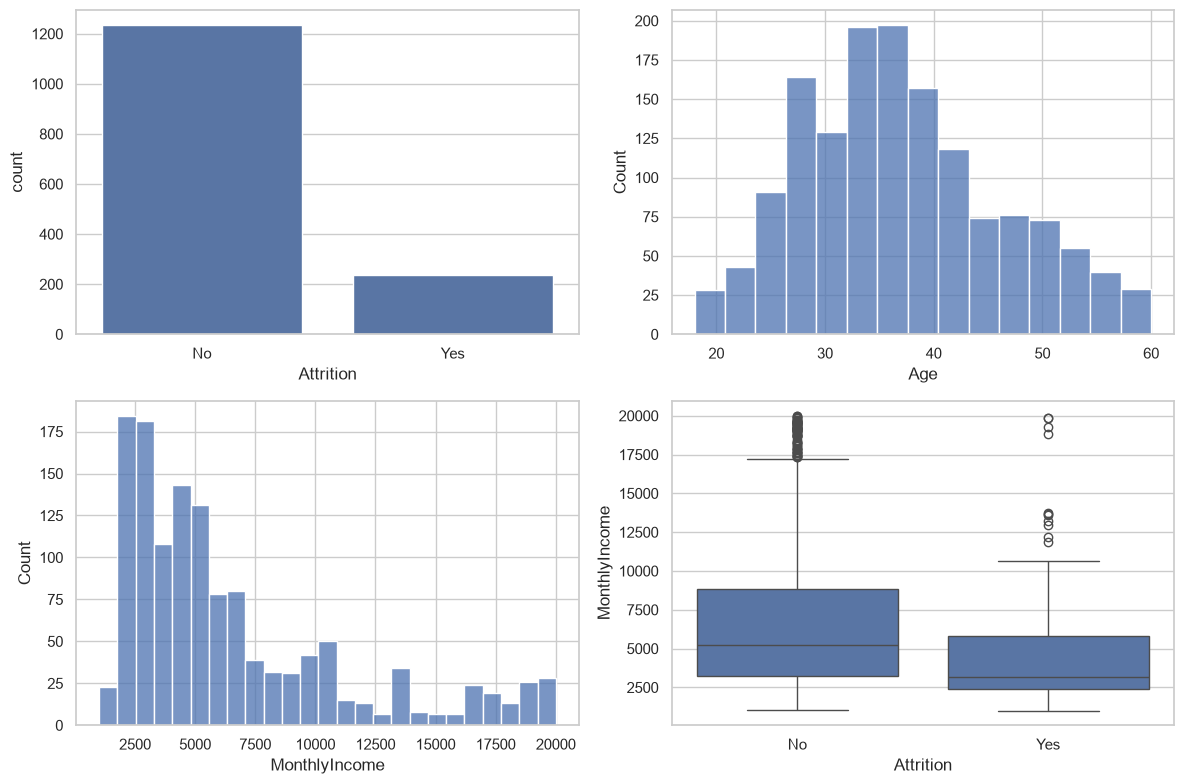

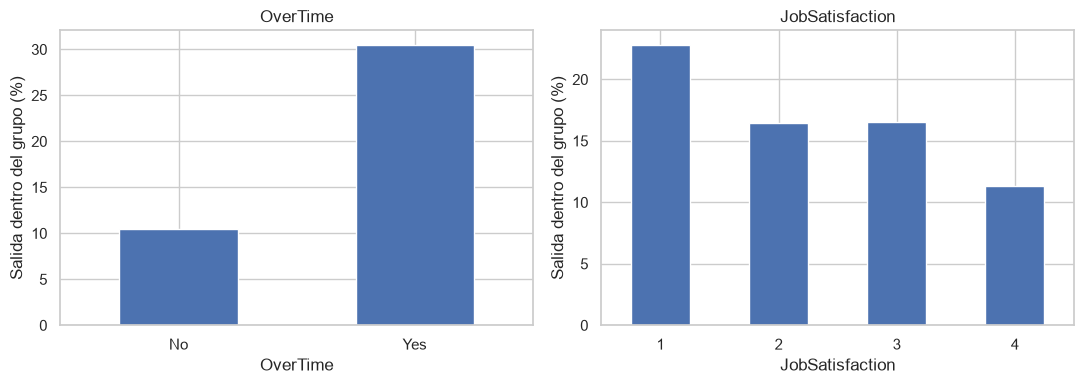

In [6]:
sns.set_theme(style='whitegrid')
fig,axes=plt.subplots(2,2,figsize=(12,8))
sns.countplot(data=analisis,x='Attrition',order=['No','Yes'],ax=axes[0,0])
sns.histplot(data=analisis,x='Age',bins=15,ax=axes[0,1])
sns.histplot(data=analisis,x='MonthlyIncome',bins=25,ax=axes[1,0])
sns.boxplot(data=analisis,x='Attrition',y='MonthlyIncome',order=['No','Yes'],ax=axes[1,1])
plt.tight_layout();plt.show()
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,c in zip(axes,['OverTime','JobSatisfaction']):
    tasas=analisis.assign(salida=analisis.Attrition.eq('Yes')).groupby(c).salida.mean()*100
    tasas.plot.bar(ax=ax,rot=0)
    ax.set_ylabel('Salida dentro del grupo (%)')
    ax.set_title(c)
plt.tight_layout();plt.show()

## 6 Estimación e intervalos del 95 %
Wilson para proporción de salida y t de Student para ingreso medio observado. La inferencia es didáctica bajo un modelo hipotético de observaciones independientes del proceso sintético; no estima parámetros de una empresa real.

In [7]:
n = len(analisis)
k = int(analisis['Attrition'].eq('Yes').sum())
p = k / n
z = stats.norm.ppf(0.975)
den = 1 + z**2 / n
centro = (p + z**2 / (2 * n)) / den
margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
ic_salida = (centro - margen, centro + margen)

x = analisis['MonthlyIncome'].dropna()
ic_ingreso = stats.t.interval(0.95, len(x) - 1, loc=x.mean(), scale=stats.sem(x))
print(f'Salida: {k}/{n} = {100*p:.2f} %')
print(f'IC Wilson del 95 %: [{100*ic_salida[0]:.2f} %, {100*ic_salida[1]:.2f} %]')
print(f'Ingreso mensual: n = {len(x)}, media = {x.mean():.2f}')
print(f'IC t del 95 %: [{ic_ingreso[0]:.2f}, {ic_ingreso[1]:.2f}]')

Salida: 237/1470 = 16.12 %
IC Wilson del 95 %: [14.33 %, 18.09 %]
Ingreso mensual: n = 1323, media = 6530.21
IC t del 95 %: [6276.27, 6784.15]


## 7 Horas extra y salida
H0: OverTime y Attrition son independientes. H1: presentan asociación. α = 0,05. Prueba chi-cuadrado de Pearson sin corrección de continuidad y V de Cramér. Se revisan frecuencias esperadas; la independencia de los registros se asume.

In [8]:
tabla=pd.crosstab(analisis.OverTime,analisis.Attrition).reindex(index=['No','Yes'],columns=['No','Yes'])
chi2,pvalor,gl,esperadas=stats.chi2_contingency(tabla,correction=False)
v=np.sqrt(chi2/(tabla.to_numpy().sum()*min(tabla.shape[0]-1,tabla.shape[1]-1)))
print(tabla)
print('Esperadas:',esperadas,'mínimo:',esperadas.min())
print(f'Chi2={chi2:.4f}; gl={gl}; p={pvalor:.6g}; V={v:.4f}')
print('Rechazar H0' if pvalor<0.05 else 'No rechazar H0')
print('Salida por grupo (%):',100*tabla.Yes/tabla.sum(axis=1))

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127
Esperadas: [[884.06938776 169.93061224]
 [348.93061224  67.06938776]] mínimo: 67.06938775510204
Chi2=89.0439; gl=1; p=3.86152e-21; V=0.2461
Rechazar H0
Salida por grupo (%): OverTime
No     10.436433
Yes    30.528846
dtype: float64
